In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

Text(0, 0.5, 'Prob')

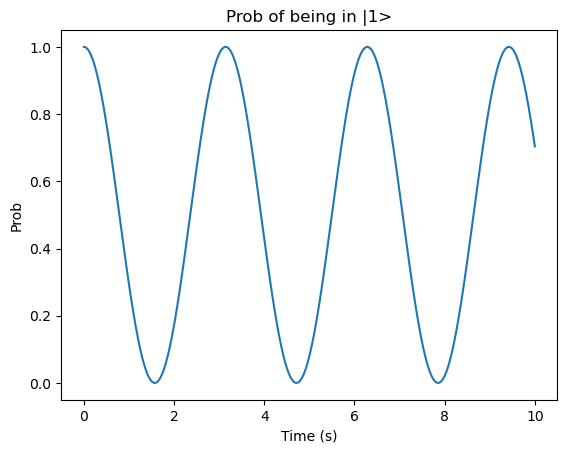

In [76]:


e1 = 1
e2 = 1
v12 = v21 = 1
h_bar = 1
ket_1 = np.array([1, 0])
bra_1 = np.transpose(ket_1)

H = np.array([[e1, v12], [v21, e2]])


start = 0
stop = 10

num_of_steps = 1000

times = np.linspace(start, stop, num_of_steps)
probs = []   

   

def exp_matrix(M, t):
    evals, evecs = np.linalg.eigh(M)    
    
    D = np.diag(evals) 
    V = np.column_stack(evecs)
    V_dag = np.linalg.inv(V)
    
    return V@(np.diag(np.exp(-1j*t/h_bar*evals)))@V_dag



for t in times:
    probs.append(np.linalg.norm(bra_1@(exp_matrix(H, t)@ket_1))**2)


    
plt.plot(times, np.array(probs))
plt.title("Prob of being in |1>")
plt.xlabel("Time (s)")
plt.ylabel("Prob")


[[1. 1.]
 [1. 1.]]


/tmp/ipykernel_108/2754204592.py:52: RuntimeWarning: divide by zero encountered in log10
  plt.plot(times, np.log10(np.abs(np.array(probs)-np.exp(-1*gamma*times))))


Text(0, 0.5, 'Log10 diff')

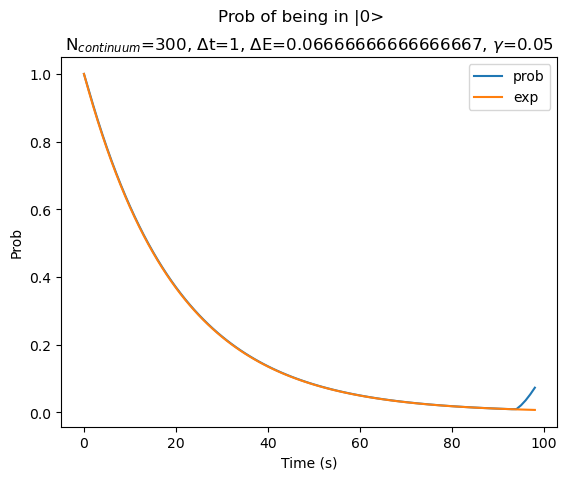

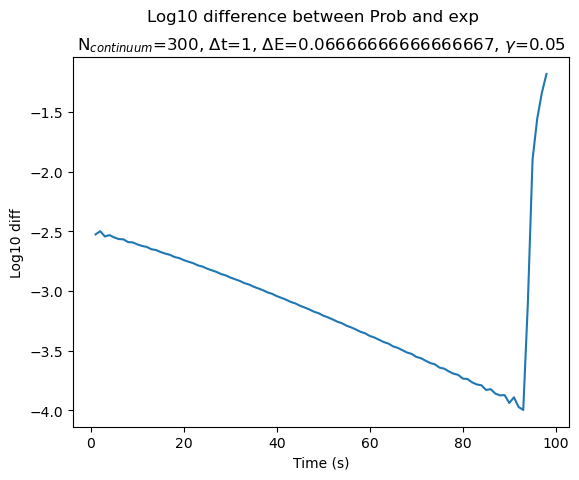

In [136]:
n = 300 # number of states in continuum
E_0 = 0 # energy of |0> state
gamma = 0.05 # decay constant
D = 10 # max/min energy of continuum states
dt = 1 # time step (s)

dE = 2*D/n # energy splitting
rho = 1/dE # density of states (rho) is number of states over range of V
v_coupling_const = np.sqrt(gamma / (2*np.pi*rho)) # assuming const potential coupling between |0> and |l>



H = np.zeros((n+1,n+1))

e = np.insert(np.linspace(-D, D, n), 0, E_0)
v = np.ones(n+1)*v_coupling_const


h_bar = 1
ket_1 = np.array(np.eye(n+1, 1))
bra_1 = np.transpose(ket_1)

H[0]=v
H[:,0]=v

np.fill_diagonal(H, e)

start = 0
stop = 2*np.pi*rho*1.05


times = np.arange(start, stop, dt)
probs = []   

   


for t in times:
    probs.append(np.linalg.norm(bra_1@(expm(-1j * H * t / h_bar)@ket_1))**2)


plt.figure(1)   
plt.plot(times, np.array(probs), label="prob")
plt.plot(times, np.exp(-1*gamma*times), label="exp")
plt.legend()
plt.suptitle("Prob of being in |0>")
plt.title(r"N$_{{continuum}}$={}, $\Delta$t={}, $\Delta$E={}, $\gamma$={}".format(n, dt, dE, gamma))
plt.xlabel("Time (s)")
plt.ylabel("Prob")

plt.figure(2)
plt.plot(times, np.log10(np.abs(np.array(probs)-np.exp(-1*gamma*times))))
plt.suptitle("Log10 difference between Prob and exp")
plt.title(r"N$_{{continuum}}$={}, $\Delta$t={}, $\Delta$E={}, $\gamma$={}".format(n, dt, dE, gamma))
plt.xlabel("Time (s)")
plt.ylabel("Log10 diff")
